In [17]:
import numpy as np
from pydrake.systems.framework import LeafSystem


class PendulumSystem(LeafSystem):
    """
    Implements: theta_ddot + theta_dot + 10*sin(theta) = u
    State: x = [theta, theta_dot]
    Input: u (scalar torque)
    """

    def __init__(self):
        super().__init__()
        self.DeclareVectorInputPort("u", 1)
        self.DeclareContinuousState(1, 1, 0)
        self.DeclareVectorOutputPort("state", 2, self.CopyStateOut)

    def DoCalcTimeDerivatives(self, context, derivatives):
        theta = context.get_continuous_state_vector()[0]
        theta_dot = context.get_continuous_state_vector()[1]
        u = self.get_input_port(0).Eval(context)[0]
        theta_ddot = u - theta_dot - 10.0 * np.sin(theta)
        derivatives.get_mutable_vector().SetFromVector([theta_dot, theta_ddot])

    def CopyStateOut(self, context, output):
        x = context.get_continuous_state_vector().CopyToVector()
        output.SetFromVector(x)


if __name__ == "__main__":
    pendulum_system = PendulumSystem()
    context = pendulum_system.CreateDefaultContext()
    context.SetContinuousState([2.1, 3.4])
    pendulum_system.get_input_port(0).FixValue(context, [7.89])
    print(context)

::_ Context
------------
Time: 0
States:
  2 continuous states
    2.1 3.4




In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pydrake.systems.framework import DiagramBuilder
from pydrake.systems.analysis import Simulator
from pydrake.systems.primitives import LogVectorOutput

#used for builidng the diagram containing the pendulum 
builder = DiagramBuilder()
pendulum = builder.AddSystem(PendulumSystem())


pendulum.get_input_port(0).FixValue

logger = LogVectorOutput(pendulum.get_output_port(0), builder)

diagram = builder.Build()

# Set up simulator
simulator = Simulator(diagram)
context = simulator.get_mutable_context()

# Set initial conditions: theta = 1.0 rad, theta_dot = 0
pendulum_context = diagram.GetMutableSubsystemContext(pendulum, context)
pendulum_context.SetContinuousState([1.0, 0.0])

# Fix the input torque to zero (undriven pendulum)
pendulum.get_input_port(0).FixValue(pendulum_context, [0.0])

# Simulate
simulator.AdvanceTo(20.0)

# Extract the log
log = logger.FindLog(context)
t = log.sample_times()
theta = log.data()[0, :]
theta_dot = log.data()[1, :]

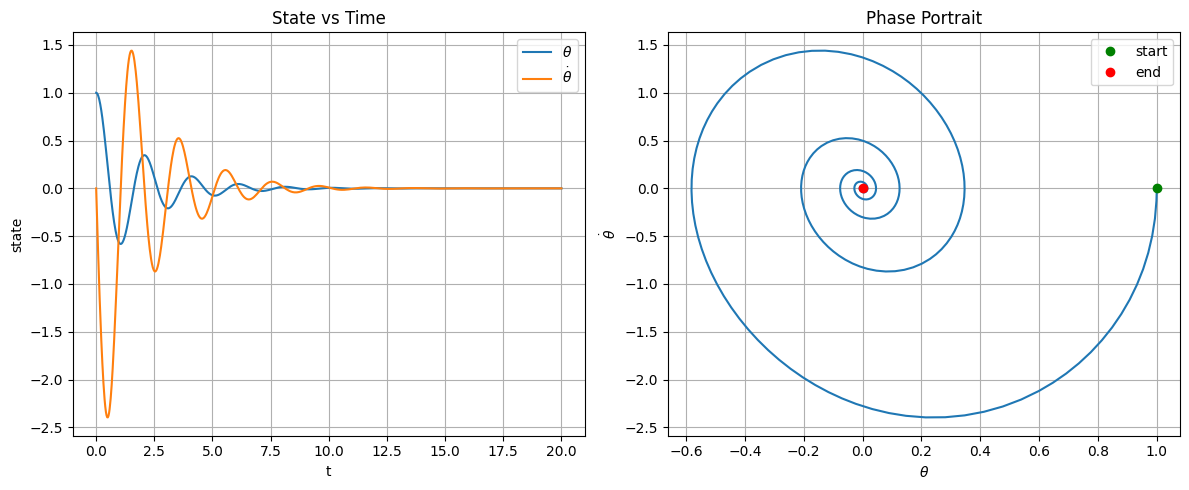

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time-domain plot
axes[0].plot(t, theta, label=r"$\theta$")
axes[0].plot(t, theta_dot, label=r"$\dot\theta$")
axes[0].set_xlabel("t")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("State vs Time")
axes[0].grid(True)

# Phase portrait
axes[1].plot(theta, theta_dot)
axes[1].plot(theta[0], theta_dot[0], 'go', label="start")
axes[1].plot(theta[-1], theta_dot[-1], 'ro', label="end")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$\dot\theta$")
axes[1].set_title("Phase Portrait")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [20]:
from underactuated.exercises.grader import Grader
from underactuated.exercises.intro.test_drake_systems import TestDrakeSystems

Grader.grade_output([TestDrakeSystems], [locals()], "results.json")
Grader.print_test_results("results.json")

Total score is 2/2.

Score for test_dynamics (underactuated.exercises.intro.test_drake_systems.TestDrakeSystems) is 1/1.

Score for test_input_and_state (underactuated.exercises.intro.test_drake_systems.TestDrakeSystems) is 1/1.
